# Exercise 6 EXTRA TASK
**Cristina Correa - 1819211867**


Read about how imbalanced data affects the models performance via: https://www.oreilly.com/library/view/introduction-to-machine/9781449369880/ch05.html

I read it and I tried to develope some code based in some blogs I found

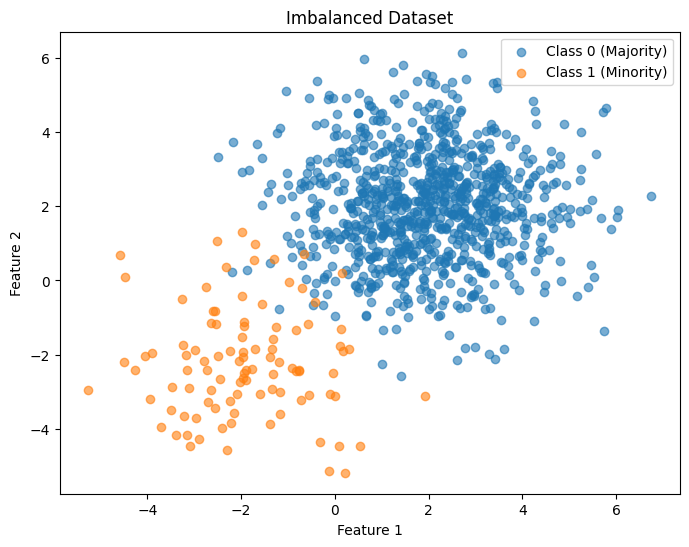

Test set accuracy: 0.98
Confusion Matrix:
[[219   4]
 [  1  26]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       223
           1       0.87      0.96      0.91        27

    accuracy                           0.98       250
   macro avg       0.93      0.97      0.95       250
weighted avg       0.98      0.98      0.98       250



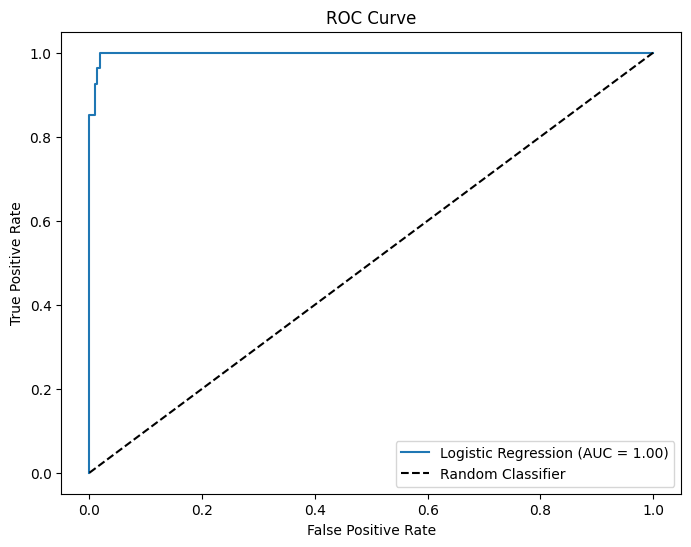

In [1]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=[900, 100], centers=[[2, 2], [-2, -2]], cluster_std=1.5, random_state=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0 (Majority)", alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1 (Minority)", alpha=0.6)
plt.legend()
plt.title("Imbalanced Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

logreg = LogisticRegression().fit(X_train, y_train)

accuracy = logreg.score(X_test, y_test)
print(f"Test set accuracy: {accuracy:.2f}")

from sklearn.metrics import confusion_matrix, classification_report

y_pred = logreg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
